In [3]:
from pathlib import Path
from datetime import datetime
import hashlib
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


PROJECT_DIR = Path("/Users/minkhant/Downloads/Grad-CAM_CarDD")

NOTEBOOK_DIR = PROJECT_DIR / 'notebooks'
if not (NOTEBOOK_DIR / 'experiment_utils.py').is_file():
    raise FileNotFoundError('Set PROJECT_DIR to the vehicle-damage project directory.')
sys.path.insert(0, str(NOTEBOOK_DIR))
import tensorflow as tf
import experiment_utils as eu

OUTPUT_DIR = PROJECT_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)
print('Python:', sys.executable)
print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))
print('CPU execution is supported if no GPU is listed.')


Python: /Users/minkhant/Downloads/Grad-CAM_CarDD/.venv/bin/python
TensorFlow: 2.21.0
GPU devices: []
CPU execution is supported if no GPU is listed.


In [5]:
# Set to a saved training run path to evaluate a specific model.
TRAINING_RUN_DIR = None

# >>> MANUAL IoU THRESHOLD OVERRIDE <<<
# None = best validation threshold; otherwise enter your chosen value in (0, 1].
IOU_THRESHOLD_OVERRIDE = 0.2

if TRAINING_RUN_DIR is None:
    pointer = OUTPUT_DIR / 'latest_run.json'
    if not pointer.exists():
        raise FileNotFoundError('Run training through validation threshold selection first.')
    TRAINING_RUN_DIR = Path(json.loads(pointer.read_text())['run_dir'])
else:
    TRAINING_RUN_DIR = Path(TRAINING_RUN_DIR).expanduser().resolve()
config = json.loads((TRAINING_RUN_DIR / 'training_config.json').read_text())
protocol = json.loads((TRAINING_RUN_DIR / 'evaluation_protocol.json').read_text())
if config['class_names'] != eu.CLASS_NAMES:
    raise ValueError('Saved model class order differs from utilities.')
selected_threshold = (float(protocol['selected_threshold']) if IOU_THRESHOLD_OVERRIDE is None
                      else float(IOU_THRESHOLD_OVERRIDE))
if not 0 < selected_threshold <= 1:
    raise ValueError('IoU threshold must be in (0, 1].')
TARGET_SIZE = tuple(config['target_size'])
BATCH_SIZE = 32
SEED = config['seed']
GRADCAM_LAYER = protocol['layer_name']
TARGET_MODE = protocol['target_mode']
tf.keras.utils.set_random_seed(SEED)
EVAL_DIR = TRAINING_RUN_DIR / datetime.now().strftime('test_%Y%m%d_%H%M%S_%f')
EVAL_DIR.mkdir()
print('Training run:', TRAINING_RUN_DIR)
print('Automatic threshold:', protocol['selected_threshold'])
print('Applied threshold:', selected_threshold)
print('Manual override:', IOU_THRESHOLD_OVERRIDE)


Training run: /Users/minkhant/Downloads/Grad-CAM_CarDD/output/run_20261007_185017_441762
Automatic threshold: 0.2
Applied threshold: 0.2
Manual override: 0.2


In [6]:
DATA_DIR = PROJECT_DIR / 'data'
MANIFEST_PATH = PROJECT_DIR / 'processed' / 'padding_25pct_per_side' / 'sample_manifest.csv'
if hashlib.sha256(MANIFEST_PATH.read_bytes()).hexdigest() != config['manifest_sha256']:
    raise ValueError('Manifest changed since training. Select the matching training run/manifest.')
for split, folder in eu.SPLIT_FOLDERS.items():
    path = DATA_DIR / 'annotations' / f'instances_{folder}.json'
    if hashlib.sha256(path.read_bytes()).hexdigest() != config['annotation_sha256'][split]:
        raise ValueError(f'{split} annotations changed since training.')
test_samples = eu.load_manifest(MANIFEST_PATH, split='test')
annotations = eu.load_annotations(DATA_DIR, splits=('test',))
test_ds = eu.make_dataset(test_samples, BATCH_SIZE, TARGET_SIZE)
model = tf.keras.models.load_model(TRAINING_RUN_DIR / 'best_model.keras', compile=False)
if tuple(model.input_shape[1:3]) != TARGET_SIZE or model.output_shape[-1] != len(eu.CLASS_NAMES):
    raise ValueError('Model dimensions do not match the saved configuration.')
eu.save_json(EVAL_DIR / 'test_protocol.json', {
    **protocol, 'selected_threshold': selected_threshold,
    'automatic_validation_threshold': protocol['selected_threshold'],
    'manual_override': IOU_THRESHOLD_OVERRIDE, 'training_run': str(TRAINING_RUN_DIR),
    'model_sha256': hashlib.sha256((TRAINING_RUN_DIR / 'best_model.keras').read_bytes()).hexdigest(),
    'manifest_sha256': config['manifest_sha256'], 'batch_size': BATCH_SIZE,
    'tensorflow_version': tf.__version__, 'test_samples': len(test_samples),
})
print('Test crops:', len(test_samples))


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Test crops: 785


25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step


accuracy              0.886624
macro_precision       0.907931
weighted_precision    0.886104
macro_recall          0.914160
weighted_recall       0.886624
macro_f1              0.910640
weighted_f1           0.886064
dtype: float64

,class,precision,recall,f1,support
0,dent,0.872247,0.838983,0.855292,236
1,scratch,0.875000,0.889251,0.882068,307
2,crack,0.820896,0.785714,0.802920,70
3,glass shatter,0.986111,1.000000,0.993007,71
4,lamp broken,0.893333,0.971014,0.930556,69
5,tire flat,1.000000,1.000000,1.000000,32


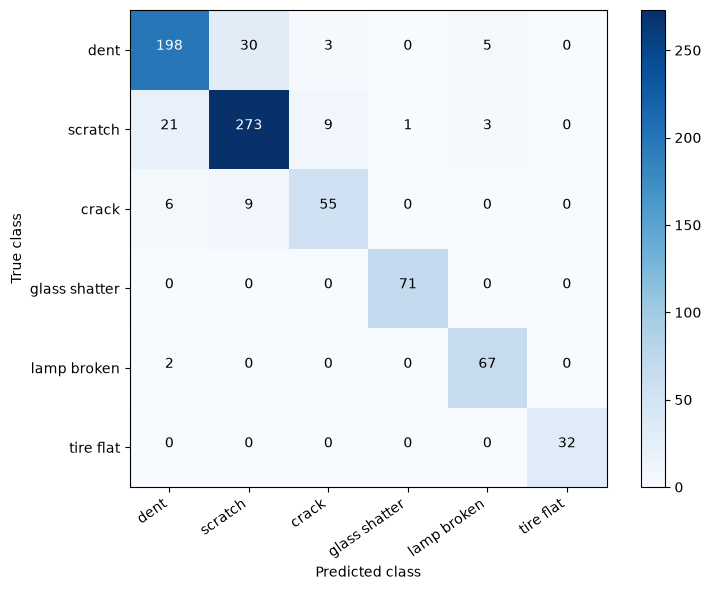

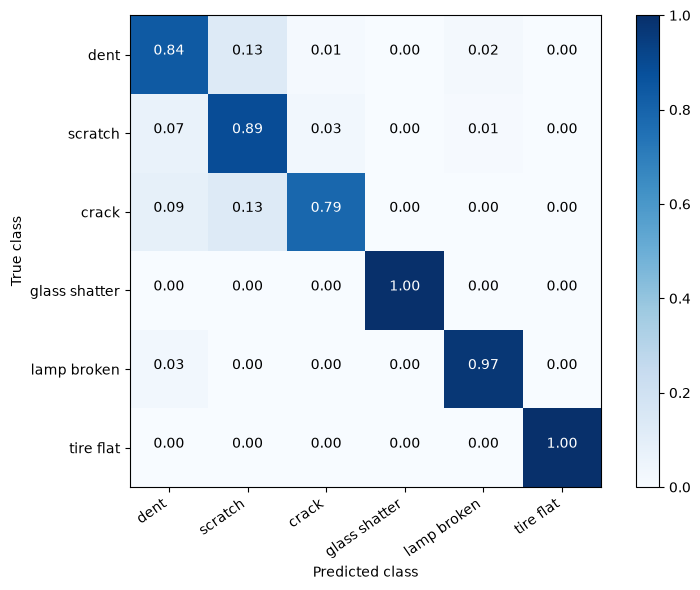

In [7]:
predictions, report, metrics, matrix = eu.evaluate_classification(model, test_ds, test_samples)
predictions.to_csv(EVAL_DIR / 'test_predictions.csv', index=False)
report.to_csv(EVAL_DIR / 'test_classification_report.csv', index=False)
eu.save_json(EVAL_DIR / 'test_classification_metrics.json', metrics)
np.save(EVAL_DIR / 'test_confusion_matrix.npy', matrix)
display(pd.Series(metrics)); display(report)
for normalized in (False, True):
    fig = eu.plot_confusion_matrix(matrix, normalize=normalized)
    fig.savefig(EVAL_DIR / f'test_confusion_matrix_{normalized}.png', dpi=150, bbox_inches='tight')
    plt.show()


In [8]:
test_cache = eu.collect_gradcam(model, test_samples, TARGET_SIZE, BATCH_SIZE,
                               target_mode=TARGET_MODE, layer_name=GRADCAM_LAYER)
np.savez_compressed(EVAL_DIR / 'test_gradcam.npz', **test_cache)
localization, localization_summary = eu.evaluate_localization(
    test_samples, annotations, test_cache, [selected_threshold])
localization.to_csv(EVAL_DIR / 'test_localization.csv', index=False)
localization_summary.to_csv(EVAL_DIR / 'test_localization_summary.csv', index=False)
per_class = localization.groupby('category').agg(mean_iou=('iou', 'mean'),
    pointing_accuracy=('pointing_hit', 'mean'), samples=('sample_id', 'size'),
    informative_fraction=('informative', 'mean'))
per_class.to_csv(EVAL_DIR / 'test_localization_per_class.csv')
display(localization_summary); display(per_class)
combined = predictions.merge(localization, on='sample_id', validate='one_to_one', suffixes=('', '_localization'))
combined.to_csv(EVAL_DIR / 'test_combined_results.csv', index=False)

Grad-CAM: 32/785
Grad-CAM: 320/785
Grad-CAM: 640/785
Grad-CAM: 785/785


,threshold,mean_iou,pointing_accuracy,informative_fraction,samples,whole_crop_mean_iou,macro_class_iou
0,0.2,0.385397,0.695541,0.997452,785,0.314625,0.442213


,mean_iou,pointing_accuracy,samples,informative_fraction
category,,,,
crack,0.219657,0.514286,70,0.985714
dent,0.419233,0.771186,236,1.000000
glass shatter,0.625328,0.957746,71,1.000000
lamp broken,0.597141,0.985507,69,1.000000
scratch,0.281014,0.534202,307,0.996743
tire flat,0.510905,0.875000,32,1.000000


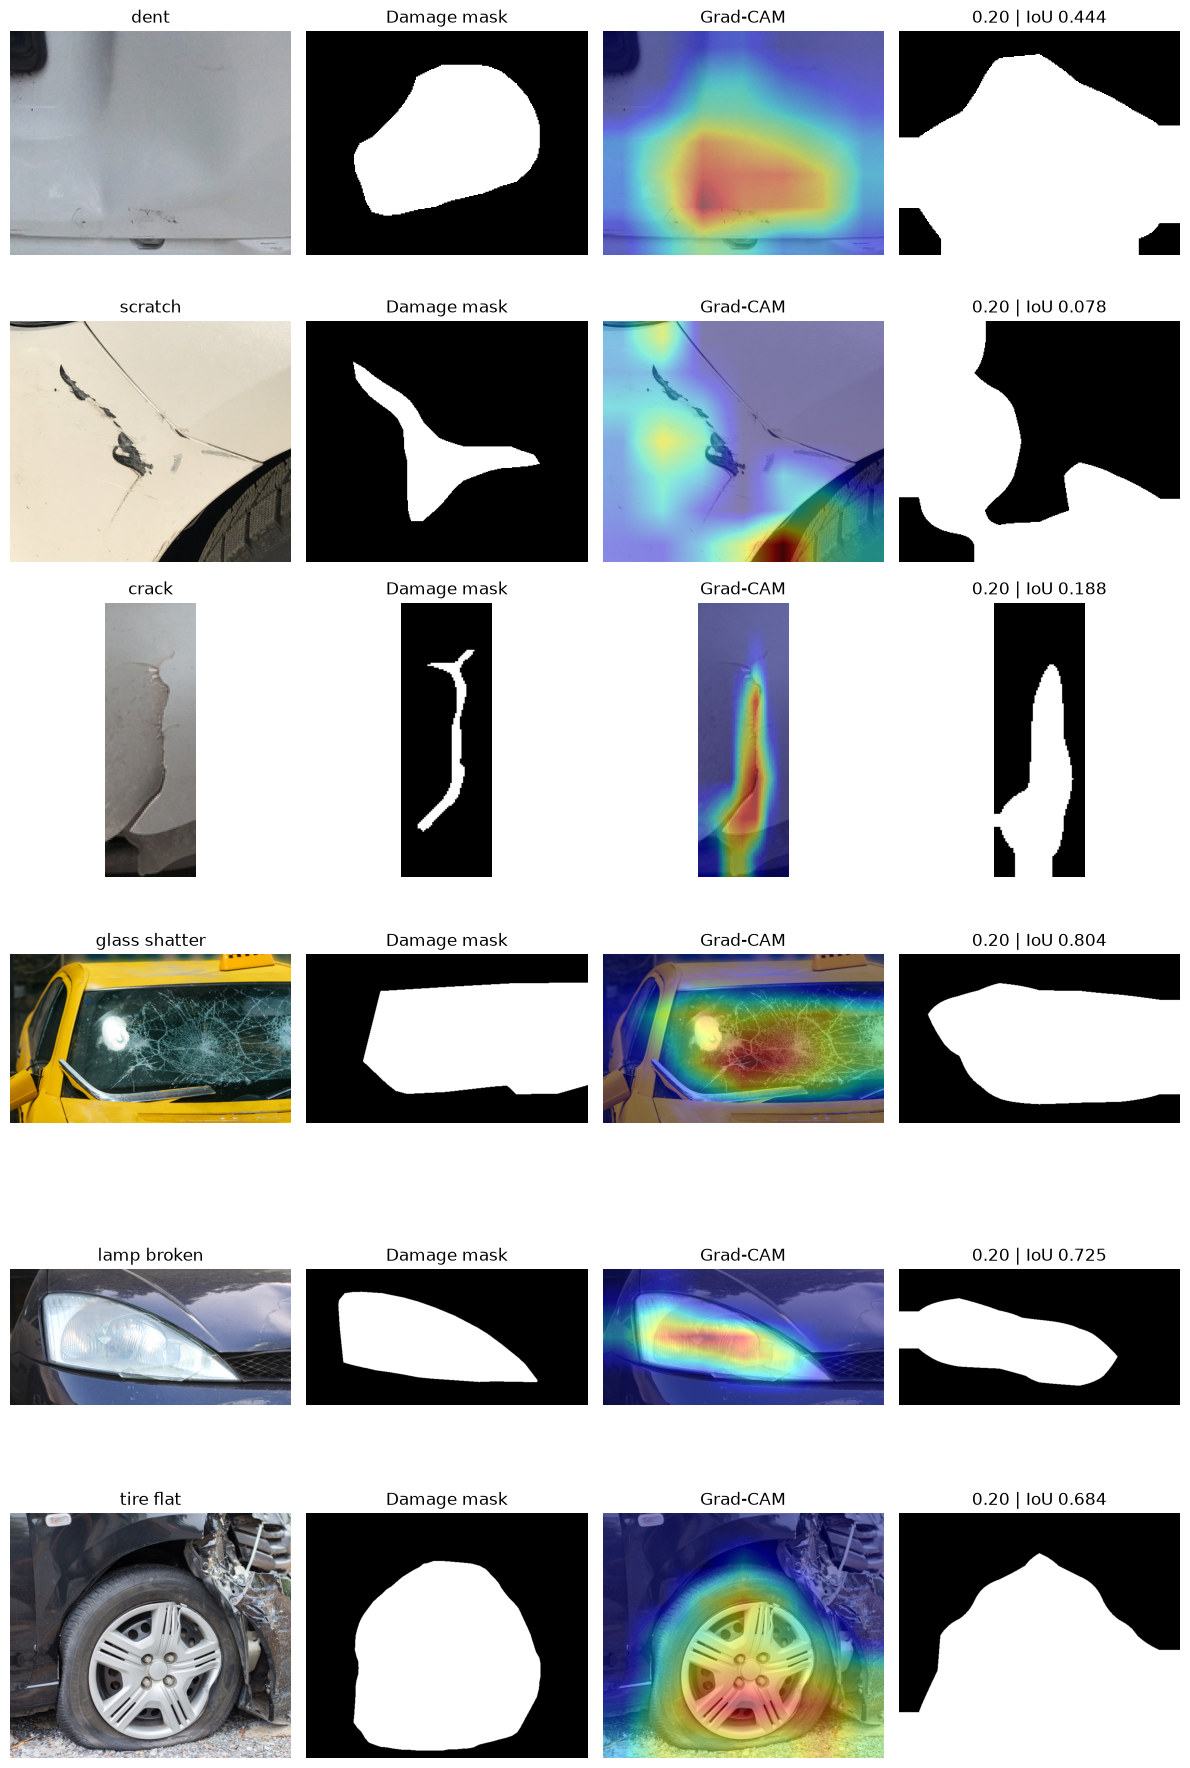

In [9]:
gallery = eu.balanced_sample(test_samples, per_class=1, seed=SEED)
gallery.to_csv(EVAL_DIR / 'test_gallery_samples.csv', index=False)
fig = eu.plot_threshold_comparison(gallery, annotations, eu.subset_cache(gallery, test_cache),
                                   [selected_threshold])
fig.savefig(EVAL_DIR / 'test_gradcam_gallery.png', dpi=150, bbox_inches='tight')
plt.show()


Sanity head: 32/785
Sanity head: 320/785
Sanity head: 640/785
Sanity head: 785/785
Sanity conv5: 32/785
Sanity conv5: 320/785
Sanity conv5: 640/785
Sanity conv5: 785/785
Sanity conv4: 32/785
Sanity conv4: 320/785
Sanity conv4: 640/785
Sanity conv4: 785/785
Sanity conv3: 32/785
Sanity conv3: 320/785
Sanity conv3: 640/785
Sanity conv3: 785/785
Sanity conv2: 32/785
Sanity conv2: 320/785
Sanity conv2: 640/785
Sanity conv2: 785/785
Sanity conv1: 32/785
Sanity conv1: 320/785
Sanity conv1: 640/785
Sanity conv1: 785/785


,stage,mean_spearman,mean_mae,valid_correlations,samples,randomized_informative_fraction
0,head,0.129744,0.237641,778,785,0.993631
1,conv5,-0.052538,0.264152,754,785,0.963057
2,conv4,0.057757,0.289903,705,785,0.899363
3,conv3,0.036365,0.300441,695,785,0.886624
4,conv2,-0.043502,0.342096,682,785,0.870064
5,conv1,0.044264,0.310127,682,785,0.870064


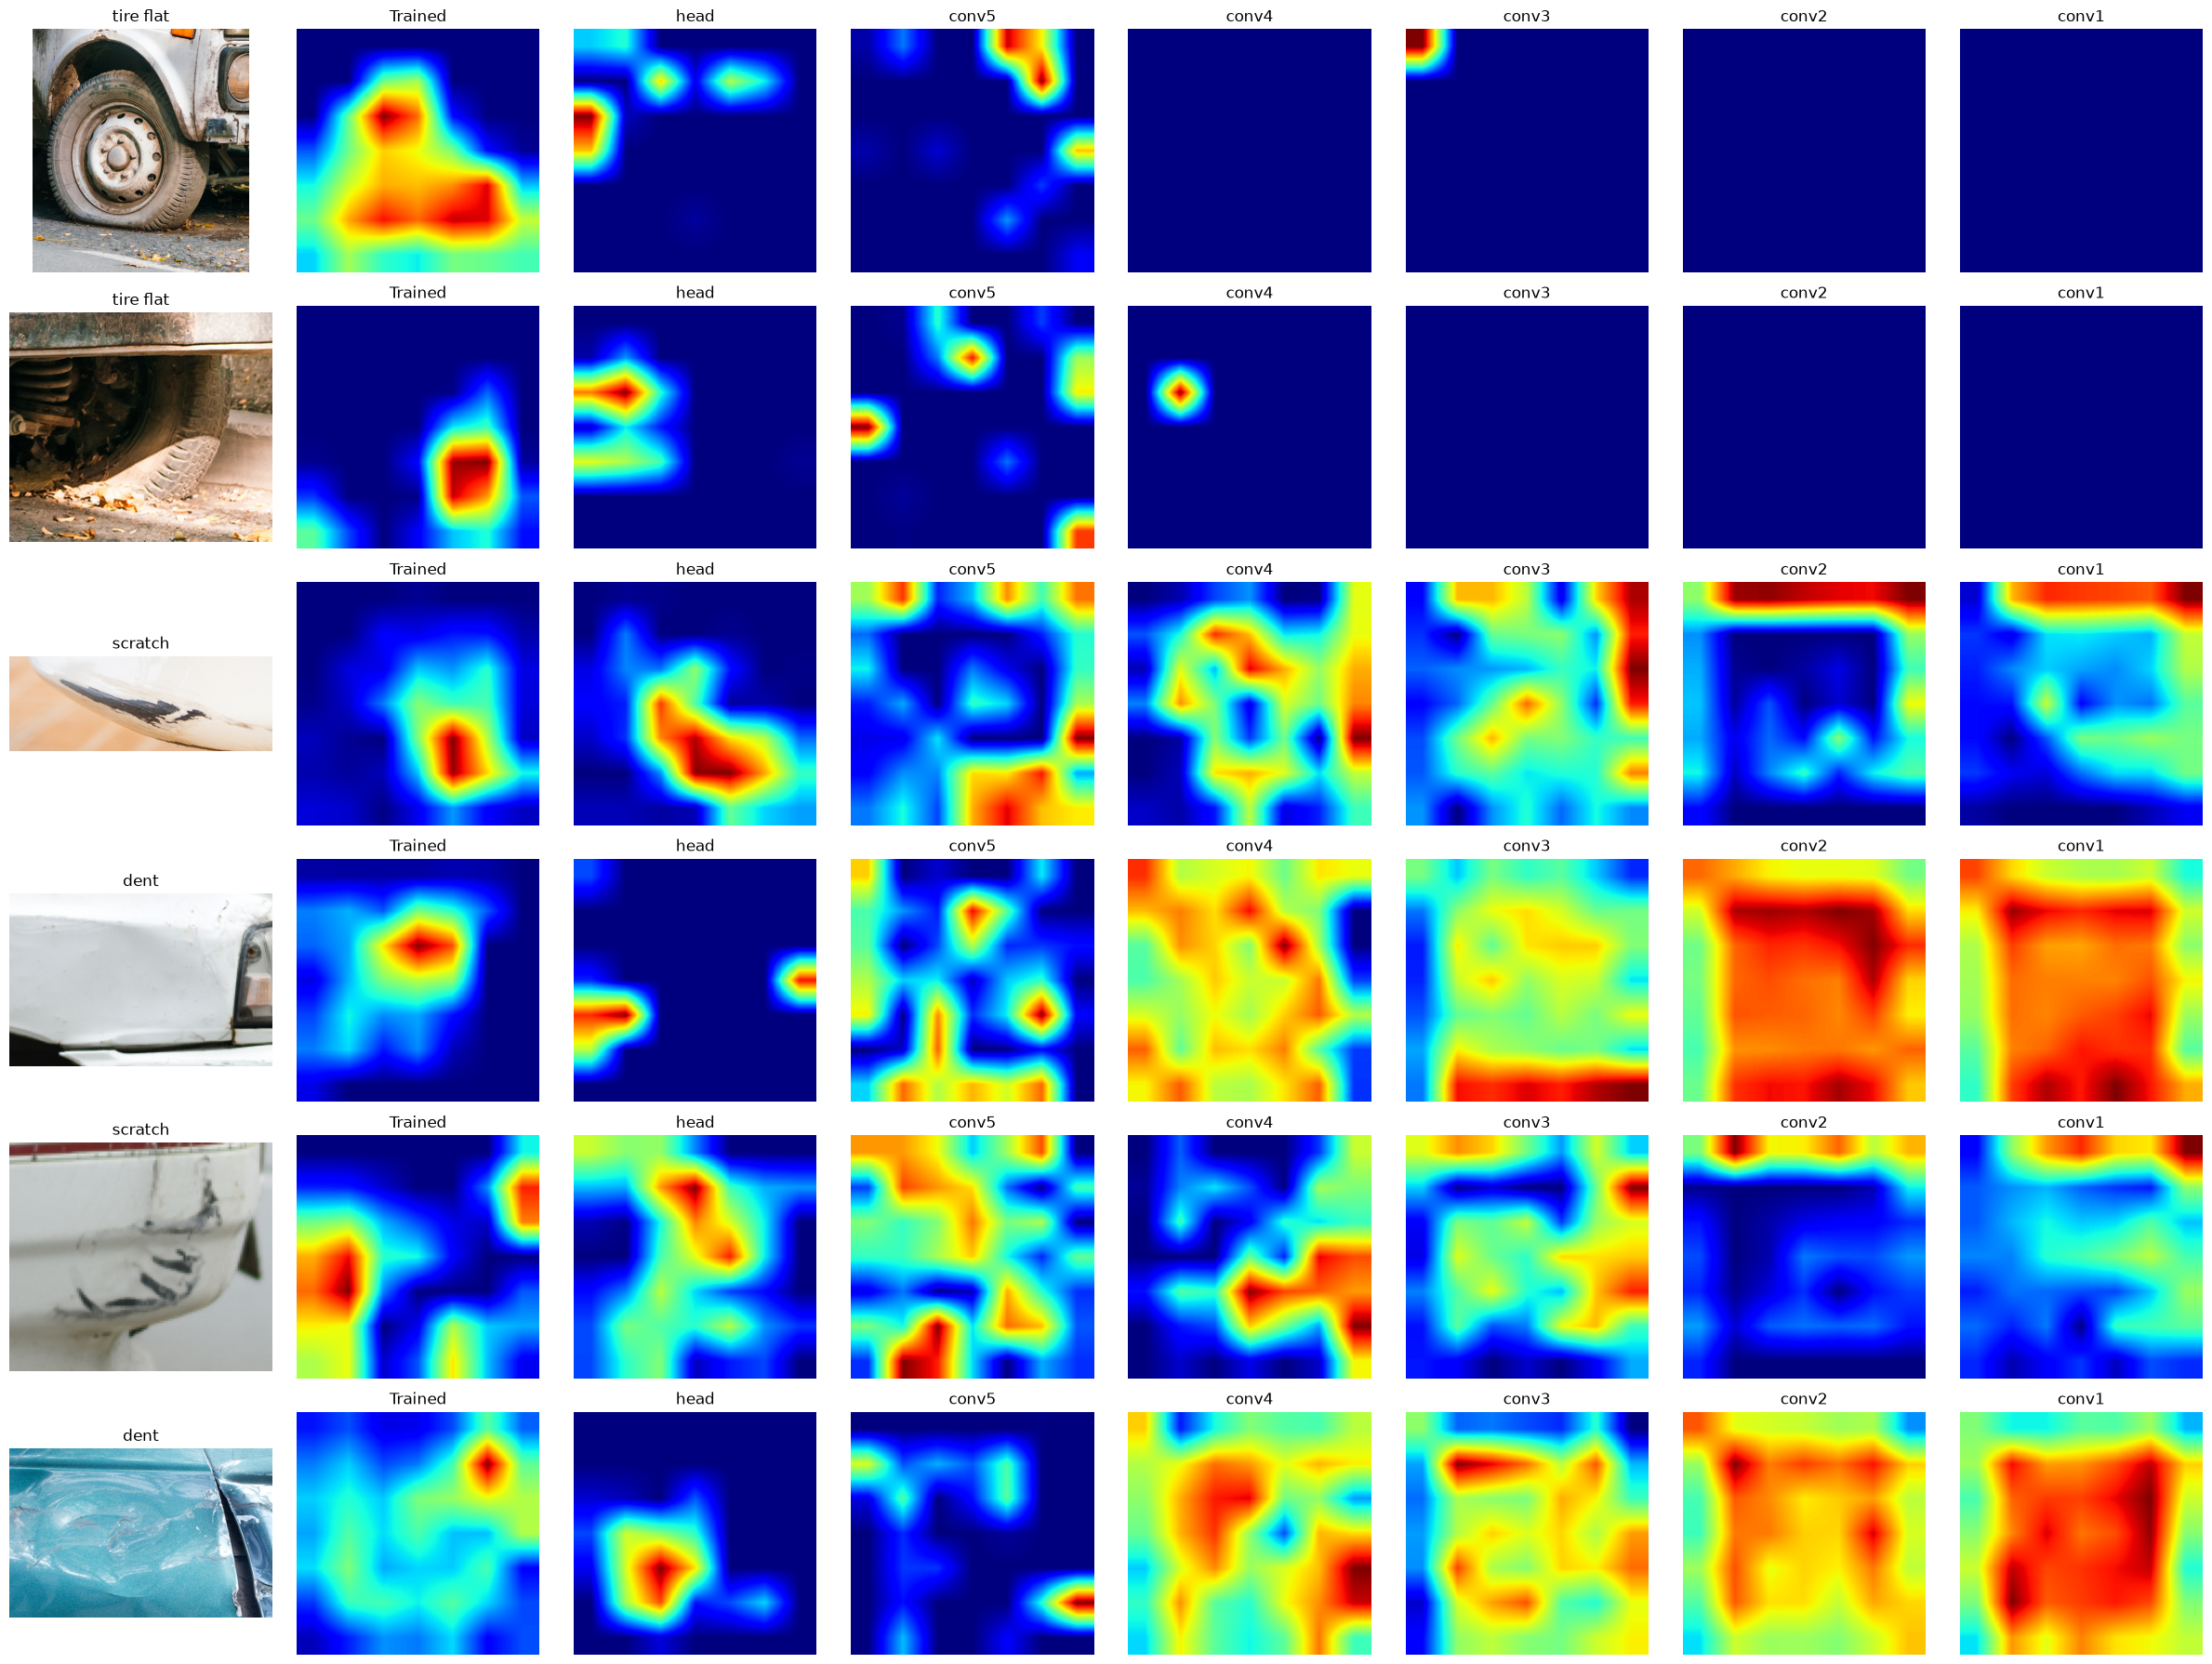

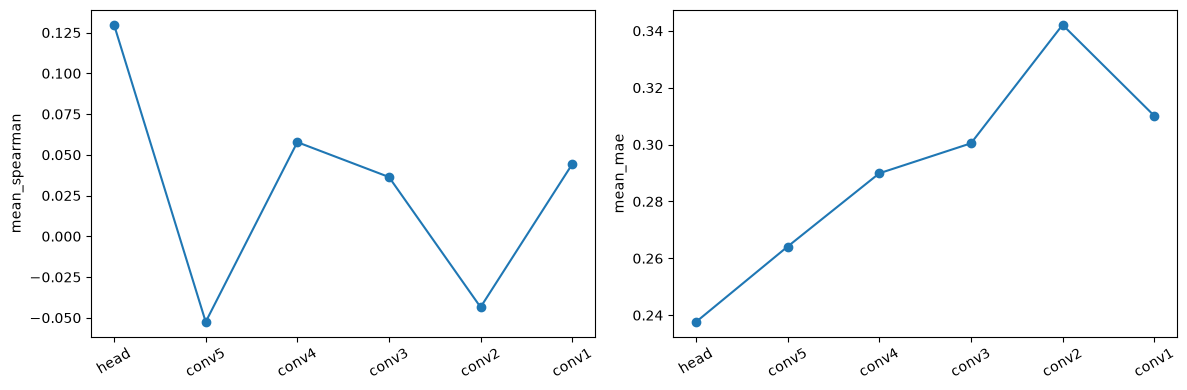

Test evaluation artifacts saved to: /Users/minkhant/Downloads/Grad-CAM_CarDD/output/run_20261007_185017_441762/test_20261007_225049_079214


In [10]:
sanity_results, sanity_summary, sanity_previews = eu.run_randomization_sanity_check(
    model, test_samples, TARGET_SIZE, BATCH_SIZE, GRADCAM_LAYER, SEED,
    baseline_cache=test_cache, output_dir=EVAL_DIR / 'test_sanity')
display(sanity_summary)
for name, fig in zip(('heatmaps', 'metrics'), eu.plot_sanity_results(
        test_samples, test_cache, sanity_summary, sanity_previews, TARGET_SIZE)):
    fig.savefig(EVAL_DIR / 'test_sanity' / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
print('Test evaluation artifacts saved to:', EVAL_DIR)
